In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Исходный диапазон: [25, 245]
Новый диапазон: [0, 50]
Разница: 50


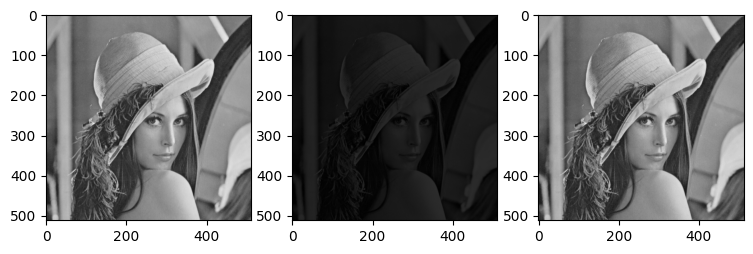

In [2]:

img = cv2.imread('data_img/Lenna.png')

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

base_min = img_gray.min()
base_max = img_gray.max()

new_min = 0
new_max = 50

img_contrasted = np.uint8(
    new_min + (img_gray.astype(np.float32) - base_min) * (new_max - new_min) / (base_max - base_min)
)

print(f"Исходный диапазон: [{base_min}, {base_max}]")
print(f"Новый диапазон: [{img_contrasted.min()}, {img_contrasted.max()}]")
print(f"Разница: {img_contrasted.max() - img_contrasted.min()}")



img_contrasted_back = np.uint8(
    base_min + (img_contrasted.astype(np.float32) - new_min) * (base_max - base_min) / (new_max - new_min)
)

plt.figure(figsize=(9, 3))
plt.subplot(131)
plt.imshow(cv2.cvtColor(img_gray,cv2.COLOR_GRAY2RGB))
plt.subplot(132)
plt.imshow(cv2.cvtColor(img_contrasted, cv2.COLOR_GRAY2RGB))
plt.subplot(133)
plt.imshow(cv2.cvtColor(img_contrasted_back,cv2.COLOR_GRAY2RGB))

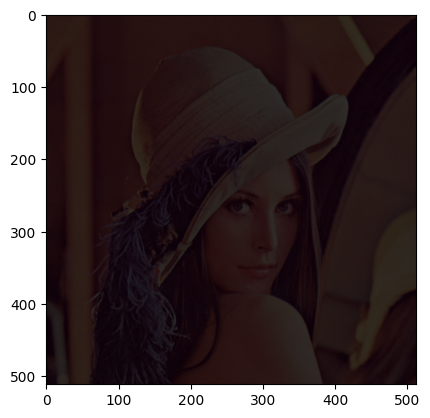

In [3]:
base_min = img.min()
base_max = img.max()

img_contrasted_bgr = np.uint8(
    new_min + (img.astype(np.float32) - base_min) * (new_max - new_min) / (base_max - base_min)
)

plt.imshow(cv2.cvtColor(img_contrasted_bgr, cv2.COLOR_BGR2RGB))
plt.show()

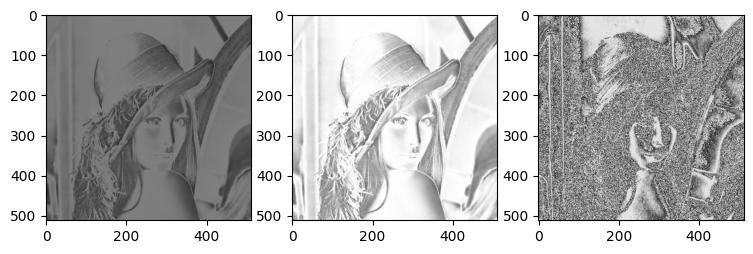

In [ ]:
pic = []
numbers = [2,4,70]
for i in numbers:
    k = i / base_max
    img_solarised = np.uint8(k * img_gray*(base_max - img_gray))
    pic.append(img_solarised)

plt.figure(figsize=(9, 3))
plt.subplot(131)
plt.imshow(cv2.cvtColor(pic[0],cv2.COLOR_GRAY2RGB))
plt.subplot(132)
plt.imshow(cv2.cvtColor(pic[1], cv2.COLOR_GRAY2RGB))
plt.subplot(133)
plt.imshow(cv2.cvtColor(pic[2],cv2.COLOR_GRAY2RGB))


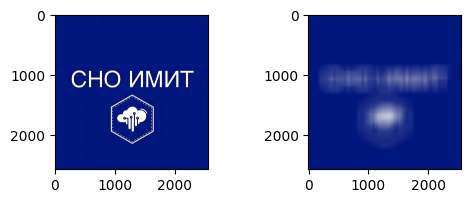

In [11]:
img_text = cv2.imread('data_img/text.jpg')
kernel_identity = np.array([[0,0,0], [0,1,0],[0,0,0]])

kernel = np.ones((255,255),np.float32) / (pow(255,2))
output = cv2.filter2D(img_text, -1, kernel)


plt.figure(figsize=(6, 2))
plt.subplot(121)
plt.imshow(cv2.cvtColor(img_text,cv2.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.show()

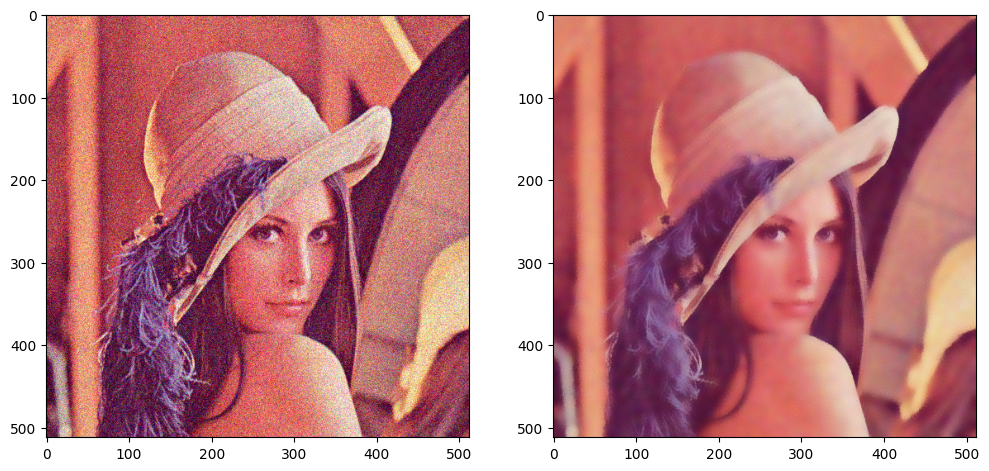

In [53]:
def add_gaussian_noise(image, mean=0, sigma=25):
    noise = np.random.normal(mean, sigma, image.shape)
    noisy_image = image + noise
    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)
    return noisy_image

noisy = add_gaussian_noise(img, mean=0, sigma=30)

blur = cv2.bilateralFilter(noisy, 15, 150, 150)

plt.figure(figsize=(12,6))
plt.subplot(121)
plt.imshow(cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(cv2.cvtColor(blur, cv2.COLOR_BGR2RGB))

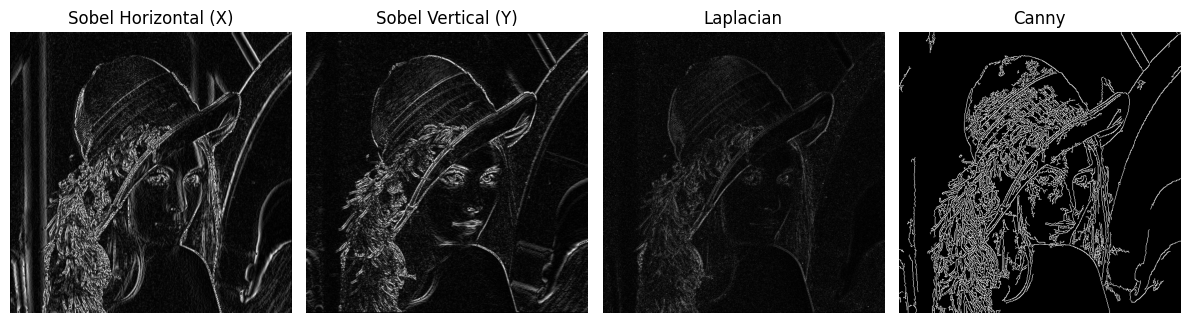

In [ ]:
GRAY = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sobelx = cv2.Sobel(GRAY, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(GRAY, cv2.CV_64F, 0, 1, ksize=3)
sobel_horizontal = np.uint8(np.absolute(sobelx))
sobel_vertical = np.uint8(np.absolute(sobely))
sobel_combined = cv2.addWeighted(sobel_horizontal, 0.5, sobel_vertical, 0.5, 0)

laplacian = cv2.Laplacian(GRAY, cv2.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

canny = cv2.Canny(GRAY, 20, 150)


plt.figure(figsize=(12, 4))


# Собель - вычисляется первая производная яркости изображения
# Где градиент большой там граница
plt.subplot(1, 4, 1)
plt.imshow(sobel_horizontal, cmap='gray')
plt.title('Sobel Horizontal (X)')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(sobel_vertical, cmap='gray')
plt.title('Sobel Vertical (Y)')
plt.axis('off')

# Вычисляется вторая производная яркости
# Где градиент меняет знак (переход через ноль), что соответствует середине резкого перепада яркости
plt.subplot(1, 4, 3)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian')
plt.axis('off')

# Сглаживание
# Вычисление градиента
# Подавление немаксимумов
# Двойная пороговая фильтрация
# Отслеживание связности
plt.subplot(1, 4, 4)
plt.imshow(canny, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.tight_layout()
plt.show()